# Static Discretization Analysis

> Goal: evaluate how discretizing continuous values into a finite menu of prices impacts revenue loss and runtime.

This notebook compares two discretization strategies implemented in the project:
- Uniform (arithmetic) grid
- Geometric (multiplicative) grid

It is organized in two parts:
1. Single-K comparison (distribution and one-shot losses)
2. Convergence analysis over increasing number of bins $K$

In [25]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we can import from the src directory
sys.path.append(os.path.dirname(os.getcwd()))
from src.discretizer import Discretizer

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Environment And Imports

This setup cell loads plotting and data libraries and imports the project `Discretizer` class from the source package.
All downstream cells depend on these imports.

In [26]:
# 1. Load the fully processed batch we created earlier
data_path = os.path.join("..", "data", "processed", "static_batch_may2019.csv")
df = pd.read_csv(data_path)

# 2. Enforce Mechanism Bounds (Individual Rationality)
# We only care about jobs with a positive Virtual Value (phi_v > 0)
# Jobs with negative phi_v are mathematically rejected by the Optimization Oracle
valid_df = df[df['phi_v'] > 0].copy()

# Keep both spaces separate for metric consistency:
continuous_v = valid_df['v'].values
continuous_phi = valid_df['phi_v'].values
q_j = valid_df['q_j'].values

LAMBDA_2 = 1.0
max_financial_continuous = float(np.sum(continuous_v))
max_objective_continuous = float(np.sum(LAMBDA_2 * q_j * continuous_phi))

print(f"Total jobs requested: {len(df)}")
print(f"Jobs accepted by Mechanism (phi_v > 0): {len(valid_df)}")
print(f"Maximum Theoretical Revenue (continuous v): ${max_financial_continuous:.2f}")
print(f"Maximum Objective Score (lambda_2 * q_j * phi_v): {max_objective_continuous:.4f}")

Total jobs requested: 1977
Jobs accepted by Mechanism (phi_v > 0): 1383
Maximum Theoretical Revenue (continuous v): $636936.44
Maximum Objective Score (lambda_2 * q_j * phi_v): 11657002.1870


## Data Scope And Mechanism Filter

We load the processed static batch and keep only jobs with $\phi_v > 0$.
This matches the mechanism decision boundary: jobs with negative virtual value are excluded from allocation.

The printed continuous sum is a reference upper bound before discretization effects.

In [27]:
K_BINS = 20
discretizer = Discretizer(K_bins=K_BINS)

results = []

# --- 1. Evaluate Uniform Grid ---
start_time = time.perf_counter()
uniform_discrete_v = discretizer.uniform_grid(continuous_v)
uniform_discrete_phi = discretizer.uniform_grid(continuous_phi)
uniform_time = time.perf_counter() - start_time

uniform_financial_loss, uniform_v_sum_cont, uniform_v_sum_disc = discretizer.calculate_financial_loss(
    continuous_v,
    uniform_discrete_v,
    return_details=True,
)
uniform_objective_loss = discretizer.calculate_objective_loss(
    continuous_phi,
    uniform_discrete_phi,
    q_j,
    lambda_2=LAMBDA_2,
)
uniform_financial_loss_pct = (uniform_financial_loss / max_financial_continuous) * 100 if max_financial_continuous else np.nan
uniform_objective_loss_pct = (uniform_objective_loss / max_objective_continuous) * 100 if max_objective_continuous else np.nan
results.append({
    "Method": "Uniform (Arithmetic)",
    "Extracted Revenue ($)": uniform_v_sum_disc,
    "Financial Loss ($)": uniform_financial_loss,
    "Financial Loss (%)": uniform_financial_loss_pct,
    "Extracted Objective Score": float(np.sum(LAMBDA_2 * q_j * uniform_discrete_phi)),
    "Objective Theoretical Loss": uniform_objective_loss,
    "Objective Theoretical Loss (%)": uniform_objective_loss_pct,
    "Execution Time (sec)": uniform_time
})

# --- 2. Evaluate Geometric Grid ---
start_time = time.perf_counter()
geometric_discrete_v = discretizer.geometric_grid(continuous_v)
geometric_discrete_phi = discretizer.geometric_grid(continuous_phi)
geometric_time = time.perf_counter() - start_time

geometric_financial_loss, geometric_v_sum_cont, geometric_v_sum_disc = discretizer.calculate_financial_loss(
    continuous_v,
    geometric_discrete_v,
    return_details=True,
)
geometric_objective_loss = discretizer.calculate_objective_loss(
    continuous_phi,
    geometric_discrete_phi,
    q_j,
    lambda_2=LAMBDA_2,
)
geometric_financial_loss_pct = (geometric_financial_loss / max_financial_continuous) * 100 if max_financial_continuous else np.nan
geometric_objective_loss_pct = (geometric_objective_loss / max_objective_continuous) * 100 if max_objective_continuous else np.nan
results.append({
    "Method": "Geometric (Multiplicative)",
    "Extracted Revenue ($)": geometric_v_sum_disc,
    "Financial Loss ($)": geometric_financial_loss,
    "Financial Loss (%)": geometric_financial_loss_pct,
    "Extracted Objective Score": float(np.sum(LAMBDA_2 * q_j * geometric_discrete_phi)),
    "Objective Theoretical Loss": geometric_objective_loss,
    "Objective Theoretical Loss (%)": geometric_objective_loss_pct,
    "Execution Time (sec)": geometric_time
})

# Display the performance matrix
results_df = pd.DataFrame(results)
display(results_df)

,Method,Extracted Revenue ($),Financial Loss ($),Financial Loss (%),Extracted Objective Score,Objective Theoretical Loss,Objective Theoretical Loss (%),Execution Time (sec)
0,Uniform (Arithmetic),402454.991506,234481.443737,36.813947,6.922978e+06,4.734024e+06,40.610994,0.000892
1,Geometric (Multiplicative),410633.755483,226302.679761,35.529869,7.078251e+06,4.578751e+06,39.278979,0.001148


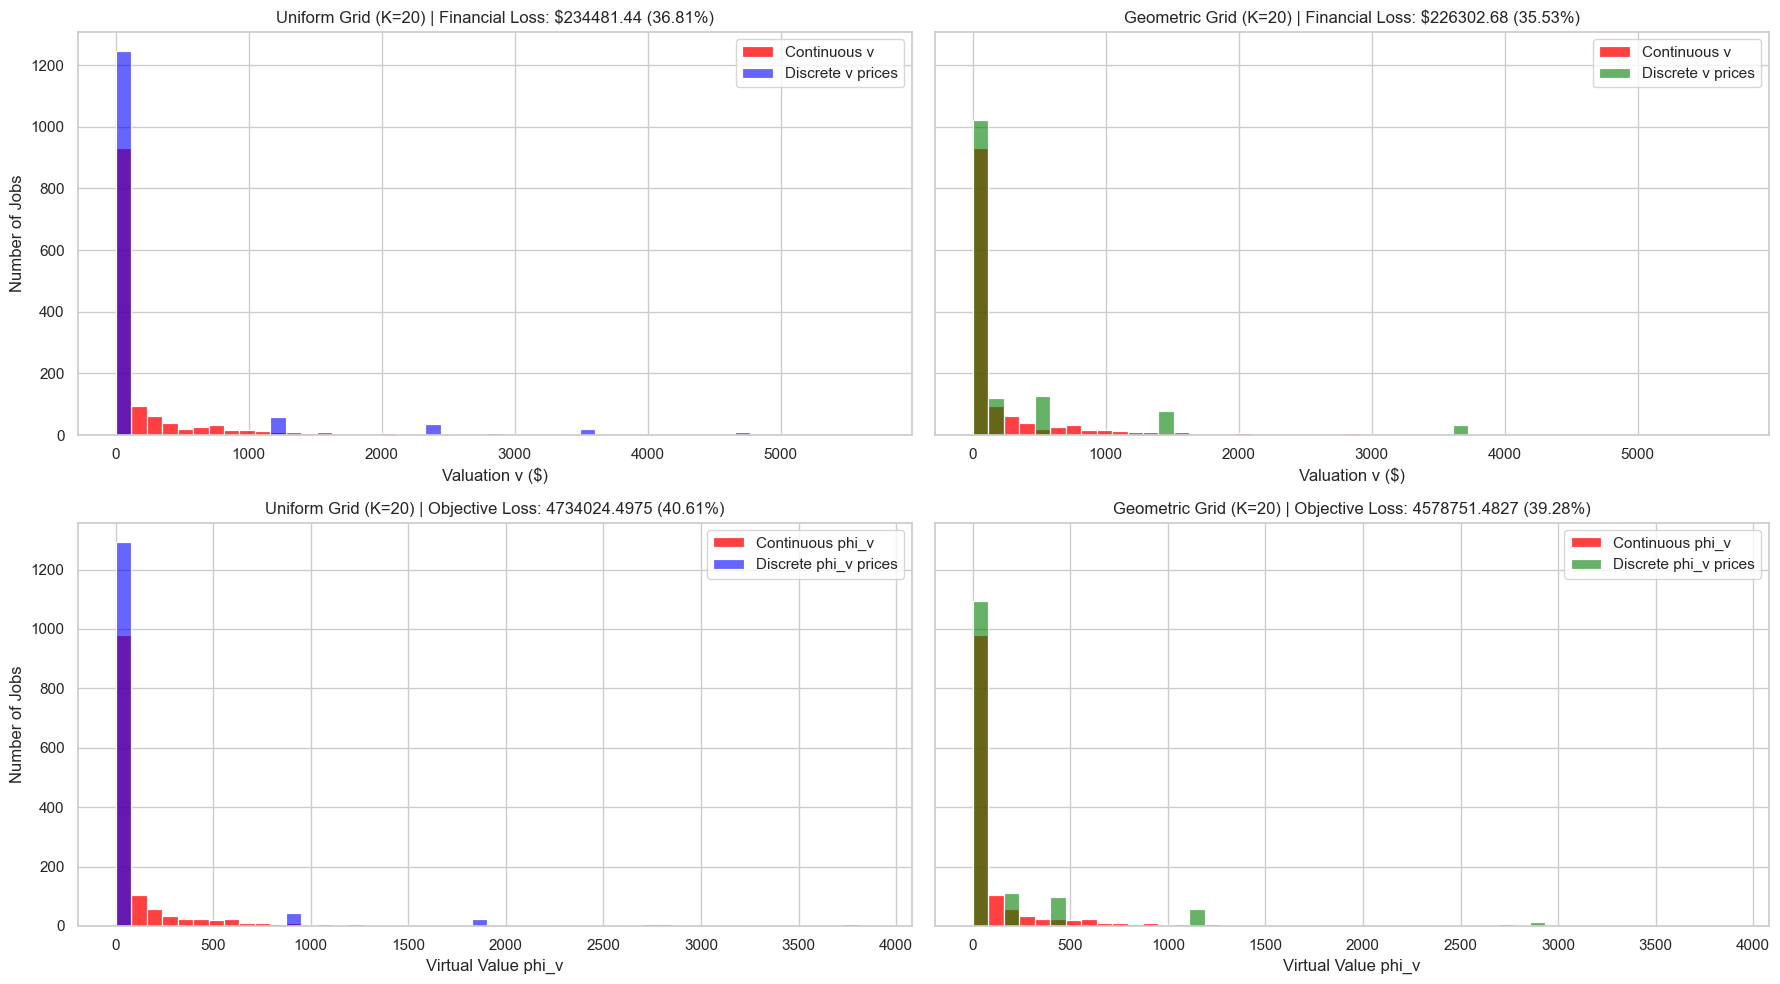

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey='row')

# Define common bins for comparability
v_bins = np.linspace(0, np.percentile(continuous_v, 99), 50)
phi_bins = np.linspace(0, np.percentile(continuous_phi, 99), 50)

# --- Top Row: v-space (Financial metric) ---
sns.histplot(continuous_v, bins=v_bins, color='red', label='Continuous v', ax=axes[0, 0], stat='count')
sns.histplot(uniform_discrete_v, bins=v_bins, color='blue', alpha=0.6, label='Discrete v prices', ax=axes[0, 0], stat='count')
axes[0, 0].set_title(
    f"Uniform Grid (K={K_BINS}) | Financial Loss: ${uniform_financial_loss:.2f} ({uniform_financial_loss_pct:.2f}%)",
    fontsize=12,
 )
axes[0, 0].set_xlabel("Valuation v ($)")
axes[0, 0].set_ylabel("Number of Jobs")
axes[0, 0].legend()

sns.histplot(continuous_v, bins=v_bins, color='red', label='Continuous v', ax=axes[0, 1], stat='count')
sns.histplot(geometric_discrete_v, bins=v_bins, color='green', alpha=0.6, label='Discrete v prices', ax=axes[0, 1], stat='count')
axes[0, 1].set_title(
    f"Geometric Grid (K={K_BINS}) | Financial Loss: ${geometric_financial_loss:.2f} ({geometric_financial_loss_pct:.2f}%)",
    fontsize=12,
 )
axes[0, 1].set_xlabel("Valuation v ($)")
axes[0, 1].legend()

# --- Bottom Row: phi-space (Objective metric) ---
sns.histplot(continuous_phi, bins=phi_bins, color='red', label='Continuous phi_v', ax=axes[1, 0], stat='count')
sns.histplot(uniform_discrete_phi, bins=phi_bins, color='blue', alpha=0.6, label='Discrete phi_v prices', ax=axes[1, 0], stat='count')
axes[1, 0].set_title(
    f"Uniform Grid (K={K_BINS}) | Objective Loss: {uniform_objective_loss:.4f} ({uniform_objective_loss_pct:.2f}%)",
    fontsize=12,
 )
axes[1, 0].set_xlabel("Virtual Value phi_v")
axes[1, 0].set_ylabel("Number of Jobs")
axes[1, 0].legend()

sns.histplot(continuous_phi, bins=phi_bins, color='red', label='Continuous phi_v', ax=axes[1, 1], stat='count')
sns.histplot(geometric_discrete_phi, bins=phi_bins, color='green', alpha=0.6, label='Discrete phi_v prices', ax=axes[1, 1], stat='count')
axes[1, 1].set_title(
    f"Geometric Grid (K={K_BINS}) | Objective Loss: {geometric_objective_loss:.4f} ({geometric_objective_loss_pct:.2f}%)",
    fontsize=12,
 )
axes[1, 1].set_xlabel("Virtual Value phi_v")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Distribution-Level Comparison At Fixed K

This figure overlays continuous values and discretized assigned prices for a fixed $K$.
Interpretation guide:
- More overlap usually implies lower discretization loss
- Stair-step concentration reveals how each method quantizes the value space
- Differences in upper-tail behavior often drive most revenue loss

## Convergence Study Across K

Now we move from a single configuration to a sweep over increasing bin counts.
Objective: find where adding more bins yields diminishing returns in loss reduction while still increasing runtime cost.

In [29]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we can import from the src directory
sys.path.append(os.path.dirname(os.getcwd()))
from src.discretizer import Discretizer

# Load dataset and filter valid jobs
data_path = os.path.join("..", "data", "processed", "static_batch_may2019.csv")
df = pd.read_csv(data_path)
valid_df = df[df['phi_v'] > 0].copy()

v_continuous = valid_df['v'].values
phi_continuous = valid_df['phi_v'].values
q_j = valid_df['q_j'].values
LAMBDA_2 = 1.0
max_financial_continuous = float(np.sum(v_continuous))
max_objective_continuous = float(np.sum(LAMBDA_2 * q_j * phi_continuous))

def run_convergence_test(
    method_name: str,
    v_values: np.ndarray,
    phi_values: np.ndarray,
    q_values: np.ndarray,
    lambda_2: float = 1.0,
    start_k: int = 2,
    step_k: int = 2,
    max_k: int = 500,
    target_threshold_pct: float = 0.1,
 ) -> pd.DataFrame:
    rows = []
    prev_financial_loss = None

    for k in range(start_k, max_k + 1, step_k):
        discretizer = Discretizer(K_bins=k)
        grid_func = discretizer.uniform_grid if method_name == "Uniform" else discretizer.geometric_grid

        start = time.perf_counter()
        v_discrete = grid_func(v_values)
        phi_discrete = grid_func(phi_values)
        elapsed = time.perf_counter() - start

        financial_loss = float(discretizer.calculate_financial_loss(v_values, v_discrete))
        objective_loss = float(discretizer.calculate_objective_loss(phi_values, phi_discrete, q_values, lambda_2=lambda_2))
        financial_loss_pct = (financial_loss / max_financial_continuous) * 100 if max_financial_continuous else np.nan
        objective_loss_pct = (objective_loss / max_objective_continuous) * 100 if max_objective_continuous else np.nan
        improvement_pct = np.nan if prev_financial_loss is None else ((prev_financial_loss - financial_loss) / prev_financial_loss) * 100 if prev_financial_loss != 0 else 0.0

        rows.append({
            "Method": method_name,
            "K": k,
            "Financial_Loss": financial_loss,
            "Financial_Loss_pct": financial_loss_pct,
            "Objective_Loss": objective_loss,
            "Objective_Loss_pct": objective_loss_pct,
            "Execution_Time_sec": elapsed,
            "Improvement_pct": improvement_pct,
        })

        if prev_financial_loss is not None and not np.isnan(improvement_pct) and improvement_pct < target_threshold_pct:
            break
        prev_financial_loss = financial_loss

    return pd.DataFrame(rows)

# Run tests (incrementing K by 2 each step)
df_uniform = run_convergence_test(
    "Uniform", v_continuous, phi_continuous, q_j, lambda_2=LAMBDA_2, start_k=2, step_k=2, max_k=500, target_threshold_pct=0.1,
 )
df_geometric = run_convergence_test(
    "Geometric", v_continuous, phi_continuous, q_j, lambda_2=LAMBDA_2, start_k=2, step_k=2, max_k=500, target_threshold_pct=0.1,
 )

# Combine for plotting
df_results = pd.concat([df_uniform, df_geometric], ignore_index=True)
df_results = df_results.sort_values(['Method', 'K']).reset_index(drop=True)
display(df_results)

,Method,K,Financial_Loss,Financial_Loss_pct,Objective_Loss,Objective_Loss_pct,Execution_Time_sec,Improvement_pct
0,Geometric,2,634633.878835,99.638495,1.158739e+07,99.402865,0.000570,NaN
1,Geometric,4,554403.988800,87.042279,1.010157e+07,86.656690,0.000435,12.641917
2,Geometric,6,456610.245103,71.688511,9.006741e+06,77.264639,0.000801,17.639437
3,Geometric,8,385929.008493,60.591448,7.448209e+06,63.894723,0.000834,15.479556
4,Geometric,10,352782.937508,55.387464,7.007351e+06,60.112806,0.000460,8.588645
...,...,...,...,...,...,...,...,...
56,Uniform,68,95571.895805,15.004935,2.459806e+06,21.101535,0.000172,2.297215
57,Uniform,70,92100.400479,14.459905,2.461487e+06,21.115954,0.000162,3.632339
58,Uniform,72,89808.174657,14.100022,2.437796e+06,20.912716,0.000165,2.488834
59,Uniform,74,89559.350853,14.060956,2.388483e+06,20.489686,0.000165,0.277061


,Method,K,Financial_Loss,Financial_Loss_pct,Objective_Loss,Objective_Loss_pct,Execution_Time_sec,Improvement_pct
0,Geometric,2,634633.878835,99.638495,1.158739e+07,99.402865,0.000570,NaN
1,Geometric,4,554403.988800,87.042279,1.010157e+07,86.656690,0.000435,12.641917
2,Geometric,6,456610.245103,71.688511,9.006741e+06,77.264639,0.000801,17.639437
3,Geometric,8,385929.008493,60.591448,7.448209e+06,63.894723,0.000834,15.479556
4,Geometric,10,352782.937508,55.387464,7.007351e+06,60.112806,0.000460,8.588645
...,...,...,...,...,...,...,...,...
56,Uniform,68,95571.895805,15.004935,2.459806e+06,21.101535,0.000172,2.297215
57,Uniform,70,92100.400479,14.459905,2.461487e+06,21.115954,0.000162,3.632339
58,Uniform,72,89808.174657,14.100022,2.437796e+06,20.912716,0.000165,2.488834
59,Uniform,74,89559.350853,14.060956,2.388483e+06,20.489686,0.000165,0.277061


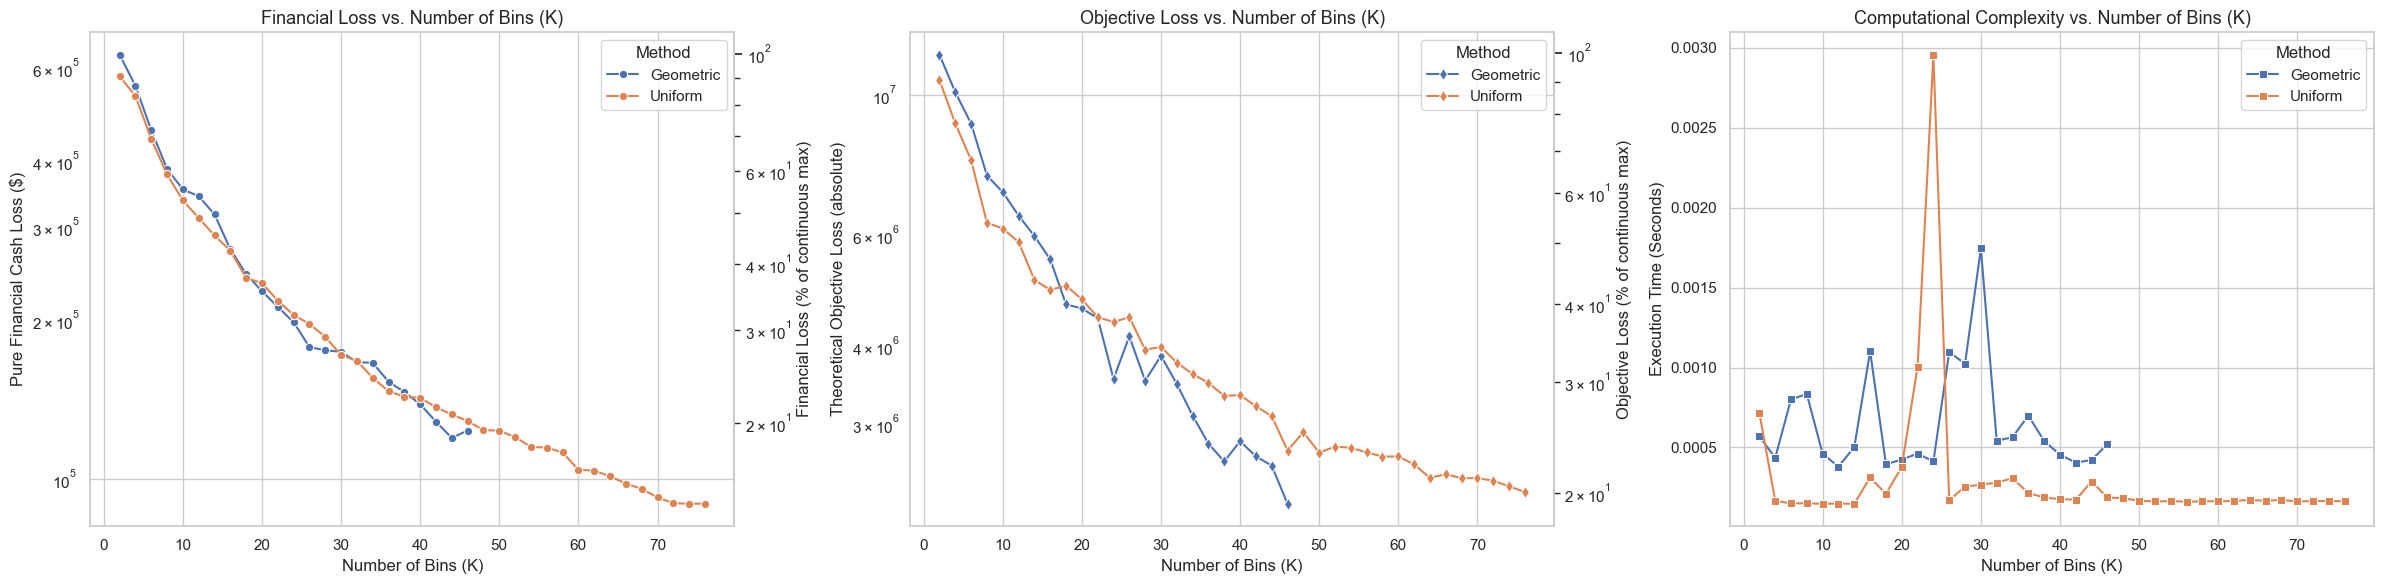

In [30]:
sns.set_theme(style="whitegrid")

# Full convergence summary for all tested K and both methods (absolute + percentage losses).
full_k_summary = df_results[[
    'Method',
    'K',
    'Financial_Loss',
    'Financial_Loss_pct',
    'Objective_Loss',
    'Objective_Loss_pct',
    'Execution_Time_sec',
    'Improvement_pct',
]].sort_values(['Method', 'K']).reset_index(drop=True)
display(full_k_summary)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# --- Plot 1: Financial Loss Convergence (v-space) ---
sns.lineplot(data=df_results, x='K', y='Financial_Loss', hue='Method', marker='o', ax=axes[0])
axes[0].set_title("Financial Loss vs. Number of Bins (K)", fontsize=13)
axes[0].set_xlabel("Number of Bins (K)")
axes[0].set_ylabel("Pure Financial Cash Loss ($)")
axes[0].set_yscale('log')
sec_ax0 = axes[0].secondary_yaxis(
    'right',
    functions=(
        lambda y: (y / max_financial_continuous) * 100,
        lambda p: (p / 100) * max_financial_continuous,
    ),
 )
sec_ax0.set_ylabel("Financial Loss (% of continuous max)")

# --- Plot 2: Objective Loss Convergence (phi-space) ---
sns.lineplot(data=df_results, x='K', y='Objective_Loss', hue='Method', marker='d', ax=axes[1])
axes[1].set_title("Objective Loss vs. Number of Bins (K)", fontsize=13)
axes[1].set_xlabel("Number of Bins (K)")
axes[1].set_ylabel("Theoretical Objective Loss (absolute)")
axes[1].set_yscale('log')
sec_ax1 = axes[1].secondary_yaxis(
    'right',
    functions=(
        lambda y: (y / max_objective_continuous) * 100,
        lambda p: (p / 100) * max_objective_continuous,
    ),
 )
sec_ax1.set_ylabel("Objective Loss (% of continuous max)")

# --- Plot 3: Time Complexity (Scalability) ---
sns.lineplot(data=df_results, x='K', y='Execution_Time_sec', hue='Method', marker='s', ax=axes[2])
axes[2].set_title("Computational Complexity vs. Number of Bins (K)", fontsize=13)
axes[2].set_xlabel("Number of Bins (K)")
axes[2].set_ylabel("Execution Time (Seconds)")

plt.tight_layout()
plt.show()